In [6]:
from functools import partial
import math
from pathlib import Path
from typing import Tuple
import warnings

from astropy.io import fits
from cytoolz import groupby, valfilter
from dustgoggles.func import gmap
from marslab.geom import transform_angle, sph2cart
from marslab.imgops.imgutils import normalize_range, enhance_color
from marslab.imgops.pltutils import despine, remove_ticks, strip_axes
from marslab.imgops.render import flatten_into_figure
from marslab.compat.mertools import add_merspect_colors_to_edgemaps
from marslab.imgops.regions import make_roi_edgemaps, draw_edgemaps_on_image
import marslab.parse as mp
import matplotlib.font_manager as mplf
from matplotlib.lines import Line2D
from more_itertools import chunked, divide
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import pdr
from scipy.interpolate import griddata
from scipy.spatial.transform import Rotation
from scipy.optimize import newton
from marslab.imgops.render import colormapped_plot

import asdf
from asdf_settings.rapidlooks import FONT_PATH
from asdf.scan import scan_zcam_files, cluster_observations
from asdf.zcam_bandset import ZcamBandSet

mpl.rcParams['image.cmap'] = 'Greys_r'
warnings.simplefilter('ignore', category=RuntimeWarning)  # i love dividing by zero

In [4]:
def open_attached(path):
    return pdr.open(path, label_fn=path, skip_existence_check=True)


def get_valid_edges(im: np.ma.MaskedArray):
    if len(im.shape) == 3:
        vy, vx = np.nonzero(np.sum(~im.mask, axis=-1))
    else:
        vy, vx = np.nonzero(~im.mask)
    valid = np.vstack([vy, vx]).T
    v_offset = np.abs(vy - im.shape[0] / 2)
    t_offset = vy
    b_offset = np.abs(vy - im.shape[0])
    h_offset = np.abs(vx - im.shape[1] / 2)
    l_offset = vx
    r_offset = np.abs(vx - im.shape[1])
    return {
        'top': valid[(t_offset + h_offset).argmin()],
        'bottom': valid[(b_offset + h_offset).argmin()],
        'left': valid[(v_offset + l_offset).argmin()],
        'right': valid[(v_offset + r_offset).argmin()]
    }


def get_cahvore(data: pdr.Data, group="GEOMETRIC_CAMERA_MODEL"):
    block = data.metablock(group)
    components = {'reference_frame': block.get('REFERENCE_COORD_SYSTEM_NAME')}
    for comp_ix, id_ in enumerate(block["MODEL_COMPONENT_ID"]):    
        components[id_] = np.array(block[f"MODEL_COMPONENT_{comp_ix + 1}"])
    components['az_fov'] = data.metaget('AZIMUTH_FOV')['value']
    components['el_fov'] = data.metaget('ELEVATION_FOV')['value']
    components['pix_w'] = data.metaget_('LINE_SAMPLES')
    components['pix_h'] = data.metaget_('LINES')
    return components


# something about this is wrong -- the valid edges are too strict, 
# or I'm multiplying the wrong vectors, or something.
def check_in_bounds(nxyz, nav_c, zcam_a):
    edges_ij = get_valid_edges(nxyz)
    nav_edgerays = {
        k: nxyz[v[0], v[1]] - nav_c for k, v in edges_ij.items()
    }
    nz_edge_cross = {
        k: np.cross(edgeray, zcam_a) for k, edgeray in nav_edgerays.items()
    }
    in_bounds_j = (np.sign(nz_edge_cross['top']) != np.sign(nz_edge_cross['bottom']))[1]
    in_bounds_i = (np.sign(nz_edge_cross['left']) != np.sign(nz_edge_cross['right']))[2]
    if in_bounds_i and in_bounds_j:
        return True
    return False


def derive_cahvore_properties(cahvore):
    for ax in ('H', 'V'):
        cahvore[f'{ax}_image'] = (
            cahvore[ax] - np.dot(cahvore['A'], cahvore[ax]) * cahvore['A']
        )
        cahvore[f'{ax}s'] = np.linalg.norm(np.cross(cahvore['A'], cahvore[ax]))
        cahvore[f'{ax}c'] = np.dot(cahvore['A'], cahvore[ax])
    cahvore['dpp_H'] = cahvore['az_fov'] / cahvore['pix_w']
    cahvore['dpp_V'] = cahvore['el_fov'] / cahvore['pix_h']
    for ax in ('H', 'V', 'A'):
        cahvore[f'{ax}u'] = cahvore[ax]/np.linalg.norm(cahvore[ax])
    return cahvore


# rough! and maybe unnecessary?
def ij_to_ray(i, j, cahv):
    i_off = i - cahv['Hc']
    j_off = j - cahv['Vc']
    rot_H = cahv['Hu'] * i_off * cahv['dpp_H']
    rot_V = cahv['Vu'] * j_off * cahv['dpp_V']
    rotate = Rotation.from_rotvec((rot_H, rot_V), degrees=True)
    return np.mean(rotate.apply(cahv['A']), axis=0)


# maybe?
def rough_valid_area(xyzmap, cahvor, slop = 0.8):
    relative_position_vecs = (xyzmap - cahvor['C'])
    rel_pos_mag = np.linalg.norm(relative_position_vecs, axis=2)
    rel_pos_u = np.einsum('ijk,ij->ijk', relative_position_vecs, 1 / rel_pos_mag)
    # plt.imshow(rel_pos_u)  # pretty!
    off_comp_h = np.dot(cahvor['Au'] - rel_pos_u, cahvor['Hu'])
    off_comp_v = np.dot(cahvor['Au'] - rel_pos_u, cahvor['Vu'])
    off_h_deg = np.abs(np.degrees(np.arcsin(off_comp_h)))
    off_v_deg = np.abs(np.degrees(np.arcsin(off_comp_v)))
    return np.nonzero(
        np.logical_and(
            off_h_deg < (cahvor['az_fov'] / (2 - slop)),
            off_v_deg < (cahvor['el_fov'] / (2 - slop))
        )
    )


def prune_xyzmap(xyzmap: np.ma.MaskedArray, cahvore: dict, slop: float=0.8):
    indices = rough_valid_area(xyzmap, cahvore, slop=slop)
    xyz = xyzmap[indices]
    assert not xyz.mask.any(), "invalid pixels have entered the xyzmap"
    return xyz.data, indices



def xyz2ij(xyz, cahvore):
    relative_positions = xyz - cahvore['C']
    omegas = np.dot(relative_positions, cahvore['O'])
    # component of rel pos vectors along omega axis
    w_omegas = np.einsum('ij,i->ij', np.array([cahvore['O'] for _ in omegas]), omegas)
    # subtract out radial distortion
    lambda3s = relative_positions - w_omegas
    # apply polynomial fit using coefficients defined in R component of model
    taus = np.einsum('ij,ij->i', lambda3s, lambda3s) / omegas ** 2
    r1, r2, r3 = cahvore['R']
    mus = r1 + r2 * taus + r3 * taus ** 2
    pps = np.einsum('ij,i->ij', lambda3s, mus) + xyz
    # fully substract out the radial distortion
    pp_cs = pps - cahvore['C']
    ppcs_dot_a = np.dot(pp_cs, cahvore['A'])
    ijvec = np.vstack(
        [
            np.dot(pp_cs, cahvore['H']) / ppcs_dot_a - 1,
            np.dot(pp_cs, cahvore['V']) / ppcs_dot_a - 1,
        ]
    ).T
    return np.round(ijvec).astype(np.int32)


def select_valid_pixels(ij, cahvore):
    validmask = (
        np.all(ij > 0, axis=1)
        & (ij[:, 0] <= cahvore['pix_w'] - 1) 
        & (ij[:, 1] <= cahvore['pix_h'] - 1) 
    )
    return np.nonzero(validmask)


def select_and_map_coordinates(xyzmap, target_cahvore):
    # optimization step
    xyz_candidates, indices = prune_xyzmap(xyzmap, target_cahvore)  
    if xyz_candidates.size == 0:
        return {}
    ij_candidates = xyz2ij(xyz_candidates, target_cahvore)
    valid_index = select_valid_pixels(ij_candidates, target_cahvore)
    ij = ij_candidates[valid_index].T
    xyz = xyz_candidates[valid_index].T
    return {
        'i': ij[0], 
        'j': ij[1], 
        'x': xyz[0], 
        'y': xyz[1], 
        'z': xyz[2],
        'si': indices[1][valid_index],
        'sj': indices[0][valid_index]
    }

def make_incidence_map(uvw, img_data):
    sun_vector = sph2cart(*transform_angle('SITE', 'ROVER', 'SOLAR', img_data))
    sun_vector = sun_vector / np.linalg.norm(sun_vector)
    deflection = np.dot(
        np.einsum('ijk,ij->ijk', uvw, 1 / np.linalg.norm(uvw, axis=2)), 
        sun_vector * -1
    )
    return np.degrees(np.arccos(deflection))

def make_rangemap(xyz, origin=(0, 0, 0)):
    return np.linalg.norm(xyz - origin, axis=-1)

def filter_navrec(navrec):
    if len(navrec['coords'].get('i', [])) == 0:
        return False
    return True

def pick_biggest_navrec(nav_recs):
    sizes = [
        len(rec['coords'].get('i', [])) for rec in nav_recs
    ]
    return nav_recs[np.argmax(sizes)]

In [3]:
from asdf.scan import scan_zcam_files, cluster_observations
from asdf.zcam_bandset import ZcamBandSet

In [ ]:
# examples:
# farfield: SOL0069_zcam03120_RSM518
# nearfield: SOL0339_zcam03308_RSM266 (ncam products on sol 337)

((9, 276),)
1


In [4]:
iof_data.show('IMAGE')

NameError: name 'iof_data' is not defined

In [6]:
def map_input_spatial_products(xyrs, iof_data, min_matched_pixels=1100):
    zc = derive_cahvore_properties(get_cahvore(iof_data))
    nav_recs = []
    for xyr_file in xyrs:
        xyr = open_attached(xyr_file)
        nxyz = np.moveaxis(xyr.get_scaled('IMAGE'), 0, 2)
        if not nxyz.any():
            continue
        nav_recs.append({'xyz': nxyz, 'fn': xyr.filename})
    for rec in nav_recs:
        rec['coords'] = select_and_map_coordinates(rec['xyz'], zc)
    nav_recs = tuple(filter(filter_navrec, nav_recs))
    if len(nav_recs) == 0:
        raise ValueError("no match between IOF and available XYRs.")
    # want a cutoff for pathological cases that are just going to map sketchy
    # data in the far corner of a navcam image -- probably like if it's under 1000 pixels,
    # don't use it
    rec = pick_biggest_navrec(nav_recs)
    if len(rec['coords']['i']) < min_matched_pixels:
        raise ValueError("Best matching XYR has < min_matched_pixels.")
    try:
        uvw_file = [
            f for f in uvwdir.iterdir()
            if f.name == Path(rec['fn']).name.replace('XYR', 'UVW')
        ][0]
        uvw_data = pdr.read(uvw_file)
        nuvw = np.moveaxis(uvw_data.get_scaled('IMAGE'), 0, 2)
        for ix, comp in enumerate(('u', 'v', 'w')):
            rec['coords'][comp] = nuvw[rec['coords']['sj'], rec['coords']['si'], ix]
        rec['uvw'], rec['uvw_path'] = nuvw, uvw_file
    except FileNotFoundError:
        warnings.warn("no surface normals file available.")
        rec['uvw'], rec['uvw_path'] = None, None
    return rec, zc


def prep_scalebar_inputs(maps, iof_data):
    xyzm = np.ma.dstack([maps['x'], maps['y'], maps['z']])
    axes = {'j': {}, 'i': {}}
    axes['j']['valid'], axes['i']['valid'] = np.nonzero(~xyzm[:, :, 0].mask)
    for ax, rec in axes.items():
        rec['unique'] = np.unique(rec['valid'])
    axes['j']['pix'] = zc['pix_h']
    axes['i']['pix'] = zc['pix_w']
    image = normalize_range(iof_data.get_scaled('IMAGE'), (0, 1), 0.1)
    sb_props = {
        "bar_font": mplf.FontProperties(
            fname=Path(FONT_PATH, "FiraMono-Medium.ttf"), 
            size=12,
            ),
        "bar_color": (0.2, 0.85, 0.95),
        "hor_j_margin": int(axes['j']['pix'] / 12),
        "vert_j_margin": int(axes['j']['pix'] / 20),
        "vert_i_margin": int(axes['i']['pix'] / 20),
        "hor_i_margin": int(axes['i']['pix'] / 3),
        "n_hor_bars": 6,
        "n_vert_bars": 3,
        "vert_bar_padding": 40,
        "i_window_size": int(axes['i']['pix'] / 10),
        "j_window_size": int(axes['i']['pix'] / 20),
        "hor_text_standoff": 13,
        "vert_text_standoff": 18
        }
    return axes, image, xyzm, sb_props

def draw_scalebars(axes, image, xyzm, sb_props):
    j_bar_pos, i_distances = compute_horizontal_scalebars(
        xyzm, 
        axes['i']['unique'], 
        axes['j']['unique'], 
        axes['i']['pix'], 
        axes['j']['pix'],
        sb_props
    )
    fig, ax = plt.subplots()
    ax.imshow(image / 2, vmax=1)
    for bar_pos, distance in zip(j_bar_pos, i_distances):
        draw_horizontal_scalebar(
            ax, bar_pos, distance, axes['i']['pix'], sb_props
        )
    for side in ('left', 'right',):
        result = compute_vertical_scalebars(
            xyzm, 
            axes['i']['unique'], 
            axes['j']['unique'], 
            axes['i']['pix'],
            axes['j']['pix'],
            sb_props,
            side,
        )
        j_bar_pos, i_bar_pos, j_distances, bar_length, vcx = result
        for pos, distance in zip(j_bar_pos, j_distances):
            draw_vertical_scalebar(
                ax, pos, i_bar_pos, distance, bar_length, sb_props, side
            )
        despine(ax)
        remove_ticks(ax)
    return fig, ax

def draw_rangemap(maps, iof_data):
    image = normalize_range(iof_data.get_scaled('IMAGE'), (0, 1), 1)
    alpha = 0.6
    image_rgb = np.dstack(
        [image] * 3 + [np.full_like(image, alpha)]
    )
    rangemap = colormapped_plot(
        maps['range'],
        layers=[image_rgb], 
        cmap='plasma',
        render_colorbar=True,
        drop_mask=False,
        n_ticks=5
    )
    return rangemap

def draw_range_contours(maps, cahvore, origin='center'):
    xyzm = np.ma.dstack([maps['x'], maps['y'], maps['z']])
    xyzm[xyzm.mask] = np.nan
    if origin == 'center':
        origin = cahvore['C']
    elif origin == 'boresight':
        origin = xyzm[int(zc['Vc']), int(zc['Hc'])]
    rangemap = make_rangemap(xyzm, origin)
    plt.style.use('dark_background')
    rclip = np.clip(
        rangemap, 
        *np.percentile(rangemap[np.isfinite(rangemap)], (0, 99))
    )
    fig, ax = plt.subplots()
    contours = ax.contour(
        np.arange(rclip.shape[1]),
        np.arange(rclip.shape[0]),
        np.flip(rclip, axis=0),
        levels=34,
        linewidths=2,
        cmap='plasma'
    )
    despine(ax)
    remove_ticks(ax)
    plt.colorbar(contours)
    return fig

In [14]:
def make_spatial_maps(coords, iof_data, cahvore):
    # make coordinate mesh
    axes = list(
        filter(lambda a: a in coords, ('x', 'y', 'z', 'u', 'v', 'w', 'si', 'sj'))
    )
    maps = {}
    ji = coords['j'], coords['i']
    iof_shape = gmap(iof_data.metaget_, ('LINES', 'LINE_SAMPLES'))
    for ax in axes:
        mesharray = np.zeros(iof_shape, np.float32)
        mesharray[ji] = coords[ax]
        maps[ax] = mesharray
    for original in ('si', 'sj'):
        mesharray = np.full(iof_shape, 0, np.int32)
        mesharray[ji] = coords[original]
        maps[original] = mesharray
    # make mask of grid positions and arrays of missing positions.
    # we use this to select points to interpolate, and we can also
    # later use this mask to get the original meshes (because the interpolated
    # products retain the original values at those points.)
    maps['meshmask'] = np.full(iof_shape, False)
    maps['meshmask'][ji] = True
    missing_ji = np.nonzero(~maps['meshmask'])
    # interpolate coordinate mesh per axis
    for ax in axes:
        values = maps[ax][ji]
        if not values[np.isfinite(values)].any():
            continue
        interpolated = griddata(ji, values, missing_ji, method='linear')
        gridarray = np.empty(iof_shape, np.float32)
        gridarray[ji] = values
        gridarray[missing_ji] = interpolated
        # just overwrite the 'mesh' values
        maps[ax] = gridarray
    maps['imask'] = ~np.isfinite(maps['x'])
    # make zcam rangemap from xyzmap
    maps['range'] = make_rangemap(
        np.dstack([maps['x'], maps['y'], maps['z']]), cahvore['C']
    ).astype('f4')
    try:
        # make zcam incidence angle map from interpolated uvwmap
        maps['incidence'] = make_incidence_map(
            np.dstack([maps['u'], maps['v'], maps['w']]), iof_data
        ).astype('f4')
    except KeyError:
        # or not
        warnings.warn("no normals available for this region.")
    return maps

In [8]:
def make_spatial_product(maps, navrec, iof_data, bandset, outpath):
    primary = fits.PrimaryHDU()
    bandset.format_metadata()
    primary.header['IN_XYR'] = Path(navrec['fn']).name
    if navrec['uvw_path'] is not None:
        primary.header['IN_UVW'] = navrec['uvw_path'].name
    else:
        primary.header['IN_UVW'] = None
    primary.header['REF_IOF'] = Path(iof_data.filename).name
    for field in (
        'SOL', 'SITE', 'DRIVE', 'SEQ_ID', 'CTIME', 'ZOOM', 'LTST', 'RSM'
    ):
        primary.header[field] = bandset.summary[field]
    hdus = [primary]
    constructor = partial(fits.CompImageHDU, quantize_method=2)
#     constructor = fits.ImageHDU
    for ax, im in maps.items():
        if ax in ("meshmask", "imask"):
            # FITS doesn't have a bool dtype
            savearray = im.astype(np.uint8)
        else:
            savearray = im.copy()
            savearray[~np.isfinite(savearray)] = 0
        hdus.append(constructor(savearray, name=ax))
    hdul = fits.HDUList(hdus)
    Path(outpath).mkdir(exist_ok=True, parents=True)
    eye = Path(iof_data.filename).name[1]
    outfile = Path(outpath, f"space_{eye}_{bandset.name}.fits")
    hdul.writeto(outfile, overwrite=True)
    return outfile

def read_space_fits(path):
    hdul = fits.open(path)
    arrays = {}
    info = hdul.info(output=False)[1:]
    imask_info = next(filter(lambda i: i[1].lower() == "imask", info))
    arrays['imask'] = hdul[imask_info[0]].data.astype(bool)
    for hdu_info in info:
        if (name := hdu_info[1].lower()) == 'imask':
            continue
        array = hdul[hdu_info[0]].data
        if name == 'meshmask':
            arrays[name] = array.astype(bool)
        else:
            arrays[name] = np.ma.masked_array(array, arrays['imask'])
        del array
    return arrays
    
def lil_roi_match(bandset, root):
    sol_path = Path(
        root, str(bandset.metadata['SOL'].iloc[0]).zfill(4)
    )
    seq, rsm = (
        bandset.metadata['SEQ_ID'].iloc[0].lower(), 
        f'RSM {bandset.metadata["RSM"].iloc[0]}'
    )
    obs_path = next(    
        filter(lambda f: seq in f.name and rsm in f.name, sol_path.iterdir())
    )
    return next(
        filter(lambda f: f.name.startswith('roi'), Path(obs_path, "data").iterdir())
    )


def make_area_array(maps):
    from cytoolz import valmap
    xyz = np.ma.dstack([maps[ax] for ax in ('x', 'y', 'z')])
    pos_vec_arrays = {
        'ud': np.diff(xyz, axis=0, prepend=xyz[0:1, :, :]),
        'du': np.diff(xyz, axis=0, append=xyz[-2:-1, :, :]),
        'lr': np.diff(xyz, axis=1, prepend=xyz[:, 0:1, :]),
        'rl': np.diff(xyz, axis=1, append=xyz[:, -2:-1, :])
    }
    distance_arrays = valmap(
        lambda a: np.linalg.norm(a, axis=2), pos_vec_arrays
    )
    return (sum(distance_arrays.values()) / 4) ** 2


def draw_area_map(image, area, bounds=(0, 90)):
    fig, ax = plt.subplots()
    scaled = np.clip(area, *np.percentile(area[np.isfinite(area)], bounds))
    image_rgb = np.dstack([image / 2] * 3 + [np.full_like(image, 0.5)])
    rangemap = colormapped_plot(
        scaled,
        layers=[image_rgb], 
        cmap='plasma',
        render_colorbar=True,
        drop_mask=False,
        n_ticks=5
    )
    return fig


def roi_rect(roi, xyz):
    j, i = np.nonzero(roi.data)
    jmin, jmax = np.min(j), np.max(j)
    imin, imax = np.min(i), np.max(i)
    center_i, center_j = int((imin + imax) / 2), int((jmin + jmax) / 2)
    jvec = xyz[jmin, center_i] - xyz[jmax, center_i]
    ivec = xyz[center_j, imin] - xyz[center_j, imax]
    return np.linalg.norm(jvec), np.linalg.norm(ivec)


def compute_roi_dims(rois, xyz, area):
    recs = []
    for name, roi in rois.items():
        color = name.split(" ")[0].lower()
        h, w = roi_rect(roi, xyz)
        rec = {
            'COLOR': color, 
            'H': h, 
            'W': w, 
            'HW': h * w, 
            'A': area[np.nonzero(roi.data)].sum()
        }
        recs.append(rec)
    return recs


def sitedrive(path):
    return (mp.site(path.name), mp.drive(path.name))


def compute_horizontal_scalebars(
    xyzm, valid_i, valid_j, ipix, jpix, sb_props, windowed_distances=True
):
    """
    compute image positions and world distances for horizontal 
    bars spaced along the j (y) axis, giving distances 
    along the i (x) axis
    """
    j_bar_pos= np.linspace(
        sb_props["hor_j_margin"], jpix - sb_props["hor_j_margin"], sb_props["n_hor_bars"]
    ).astype(np.int16)
    j_bar_pos = [
        valid_j[np.abs(valid_j - j_bar_pos[i]).argmin()]
        for i, _ in enumerate(j_bar_pos)
    ]
    i_distances = []
    for bar_pos in j_bar_pos:
        row = xyzm[bar_pos]
        valid_row_ix = np.nonzero(~row.mask.all(axis=1))[0]
        start, stop = valid_row_ix[0], valid_row_ix[-1]
        distance_ratio = (stop - start) / ipix 
        if windowed_distances is False:
            distance = np.linalg.norm(row[stop] - row[start])
        else:
            windows = tuple(chunked(valid_row_ix, sb_props["i_window_size"]))
            row_distances = []
            for window in windows:
                row_distances.append(
                    np.linalg.norm(row[
                        window[0]] - row[window[-1]])
                )
            distance = sum(row_distances)
        i_distances.append(distance / distance_ratio)
    return j_bar_pos, i_distances


def compute_vertical_scalebars(
    xyzm, valid_i, valid_j, ipix, jpix, sb_props, side = 'left'
):
    """
    compute image positions and world distances for vertical 
    bars spaced along the j (y) axis, giving distances 
    along the j (y) axis
    """
    bar_length = (
        (valid_j.max() - valid_j.min()) 
        - 2 * sb_props["vert_j_margin"]
        - sb_props["vert_bar_padding"] * sb_props["n_vert_bars"]
    ) / sb_props["n_vert_bars"]
    j_bar_pos = [
        valid_j.min() 
        + sb_props["vert_j_margin"] 
        + i * sb_props["vert_bar_padding"] 
        + i * bar_length 
        + sb_props["vert_bar_padding"] / 2
        for i in range(sb_props["n_vert_bars"])
    ]
    if side == 'left':
        i_bar_pos = sb_props["vert_i_margin"] 
    else:
        i_bar_pos = ipix - sb_props["vert_i_margin"]
    real_i_bar_pos = [valid_i[np.abs(valid_i - i_bar_pos).argmin()]]
    col = xyzm[:, real_i_bar_pos]
    valid_col_ix = np.unique(np.nonzero(~col.mask.all(axis=1))[0])
    j_distances = []
    for pos in j_bar_pos:
        start_ix = np.argmin(np.abs(valid_col_ix - pos))
        stop_ix = np.argmin(np.abs(valid_col_ix - (pos + bar_length)))
        start = valid_col_ix[start_ix]
        stop = valid_col_ix[stop_ix]
        distance_ratio = (stop_ix - start_ix) / bar_length
        distance = np.linalg.norm(
            xyzm[start, real_i_bar_pos] - xyzm[stop, real_i_bar_pos]
        )
        j_distances.append(distance / distance_ratio)
    return j_bar_pos, i_bar_pos, j_distances, bar_length, valid_col_ix


def lformat(length, digits=1):
    if length < 1:
        length, units = length * 100, "cm"
    else:
        units = "m"
    return f"{str(round(length, digits))}{units}"

def draw_horizontal_scalebar(ax, bar_pos, distance, ipix, sb_props):
    distance_ratio = (ipix - 2 * sb_props["hor_i_margin"]) / ipix
    line = Line2D(
        [sb_props["hor_i_margin"], ipix - sb_props["hor_i_margin"]],
        [bar_pos, bar_pos],
        marker='|',
        markersize=15,
        markeredgewidth=3,
        lw=3,
        c=sb_props["bar_color"]
    )
    ax.add_artist(line)
    ax.annotate(
        lformat(distance * distance_ratio), 
        (int(ipix / 2), bar_pos - sb_props["hor_text_standoff"]),
        ha='center',
        fontproperties=sb_props["bar_font"],
        color=sb_props["bar_color"]
    )
    return ax


def draw_vertical_scalebar(
    ax, j_bar_pos, i_bar_pos, distance, bar_length, sb_props, side='left'
):
    line = Line2D(
        [i_bar_pos, i_bar_pos],
        [j_bar_pos, j_bar_pos + bar_length],
        marker='_',
        markersize=15,
        markeredgewidth=3,
        lw=3,
        c=sb_props["bar_color"]
    )
    ax.add_artist(line)
    if side == 'left':
        standoff = sb_props["vert_text_standoff"] 
    else:
        # ??
        standoff = -5 * sb_props["vert_text_standoff"]
    ax.annotate(
        lformat(distance), 
        (i_bar_pos + standoff, j_bar_pos + bar_length / 2),
        va='center',
        fontproperties=sb_props["bar_font"],
        color=sb_props["bar_color"],
        rotation=90
    )
    return ax

def draw_incidence_map(incidence):
    fig, ax = plt.subplots()
    imap = ax.imshow(incidence)
    plt.colorbar(imap)
    despine(ax)
    remove_ticks(ax)
    return fig

In [9]:
plt.close('all')

In [7]:
def sitedrive(path):
    return (mp.site(path.name), mp.drive(path.name))

def lil_roi_match(bandset, root):
    sol_path = Path(
        root, str(bandset.metadata['SOL'].iloc[0]).zfill(4)
    )
    seq, rsm = (
        bandset.metadata['SEQ_ID'].iloc[0].lower(), 
        f'RSM {bandset.metadata["RSM"].iloc[0]}'
    )
    obs_path = next(    
        filter(lambda f: seq in f.name and rsm in f.name, sol_path.iterdir())
    )
    return next(
        filter(lambda f: f.name.startswith('roi'), Path(obs_path, "data").iterdir())
    )

In [8]:
root = Path('datascratch/zcam_data/products/')
zsol, nsol = 242, 239
iofdir = Path(root, str(zsol).zfill(4), 'iof')
xyrdir = Path(root, str(nsol).zfill(4), 'nxyr')
uvwdir = Path(root, str(nsol).zfill(4), 'nuvw')
zsite = groupby(sitedrive, iofdir.iterdir())
nsite = groupby(sitedrive, xyrdir.iterdir())
sd_ops = tuple(set(zsite.keys()).intersection(nsite.keys()))
sd = sd_ops[0]
iofs = scan_zcam_files(iofdir)
iofs = iofs.loc[(iofs['SITE'] == sd[0]) & (iofs['DRIVE'] == sd[1])]
clusters = cluster_observations(iofs)[0]
print(len(clusters))
xyrs = nsite[sd]
ref_band = 'R3'
bandset = ZcamBandSet(tuple(clusters.values())[0])
bandset.rois = lil_roi_match(bandset, 'datascratch/zcam_data/fdsa_hopper/')
bandset.suffix = None
meta = bandset.metadata
iof_data = bandset.precached[
    meta.loc[meta['BAND'] == ref_band, 'PATH'].iloc[0]
]

2


In [9]:
bandset.load_rois()

loaded marslab ROI FITS file

In [10]:
bandset.make_space_fits()

loading 6 candidate XYR files

loaded NRF_0239_0688164877_774XYR_N0072440NCAM03239_0A0195J03.IMG

loaded NRF_0239_0688165030_759XYR_N0072440NCAM03239_0A0195J03.IMG

loaded NRF_0239_0688165255_115XYR_N0072440NCAM03239_0A0195J03.IMG

loaded NRF_0239_0688165440_871XYR_N0072440NCAM02329_0A0195J03.IMG

...

NRF_0239_0688168279_101XYR_N0072440NCAM00767_0A00LLJ01.IMG rejected on R1: no_match

selected NRF_0239_0688165440_871XYR_N0072440NCAM02329_0A0195J03.IMG for L1

selected NRF_0239_0688165440_871XYR_N0072440NCAM02329_0A0195J03.IMG for R1

wrote data/space_L_SOL0242_zcam03245_RSM740.fits

wrote data/space_R_SOL0242_zcam03245_RSM740.fits

In [12]:
bandset.make_spatial_products()

In [11]:
bandset.load('all')
bandset.bulk_debayer('all')
bandset.count_rois()
dims = {}
for ref_band in ('L1', 'R1'):
    iof_data = bandset.precached[meta.loc[meta['BAND'] == ref_band, 'PATH'].iloc[0]]
    try:
        maps = read_space_fits(Path("test", f"space_{ref_band[0]}_{bandset.name}.fits"))
        zc = derive_cahvore_properties(get_cahvore(iof_data))
    except FileNotFoundError:
        navrec, zc = map_input_spatial_products(xyrs, iof_data)
        maps = make_spatial_maps(navrec['coords'], iof_data, zc)
        fits_path = make_spatial_product(maps, navrec, iof_data, bandset, "test")
        maps = read_space_fits(Path("test", f"space_{ref_band[0]}_{bandset.name}.fits"))
    eye = {'L': 'LEFT', 'R': 'RIGHT'}[ref_band[0]]
    image = iof_data.get_scaled('IMAGE')
    maps['area'] = make_area_array(maps)
    areaplot = draw_area_map(image, maps['area'])
    eye_rois = {r.name: r for r in bandset.rois if r.name.endswith(eye)}
    axes, image, xyzm, sb_props = prep_scalebar_inputs(maps, iof_data)
    roi_dims = pd.DataFrame(compute_roi_dims(eye_rois, xyzm, maps['area']))
    roi_dims.columns = [
        c if c == 'COLOR' else f"{eye}_{c}" for c in roi_dims.columns
    ]
    dims[eye] = roi_dims
    scalefig, scaleax = draw_scalebars(axes, image, xyzm, sb_props)
    rangefig = draw_rangemap(maps, iof_data)
    center_contour = draw_range_contours(maps, zc)
    boresight_contour = draw_range_contours(maps, zc, 'boresight')
    ifig = draw_incidence_map(maps['incidence'])
    eyepre = eye.lower()[0]
    for fig in (scalefig, rangefig, center_contour, boresight_contour, ifig):
        fig.tight_layout()
    dpi = 340
    scalefig.savefig(f"test/scalebar_{eyepre}_{bandset.name}.png", dpi=dpi)
    rangefig.savefig(f"test/rangemap_{eyepre}_{bandset.name}.png", dpi=dpi)
    center_contour.savefig(f"test/camera_contour_{eyepre}_{bandset.name}.png", dpi=dpi)
    boresight_contour.savefig(f"test/boresight_contour_{eyepre}_{bandset.name}.png", dpi=dpi)
    ifig.savefig(f"test/incidence_{eyepre}_{bandset.name}.png", dpi=dpi)
    plt.close('all')
dims = pd.merge(*tuple(dims.values()), on='COLOR')
bandset.format_metadata()
bandset.compact['ANALYSIS_NAME'] = ''
bandset.compact = pd.merge(bandset.compact, dims, on='COLOR')
bandset.compact.to_csv(f'test/marslab_w_spatial_example_{bandset.name}.csv', index=None)

NameError: name 'read_space_fits' is not defined

In [29]:
tuple(dims.values())

TypeError: 'numpy.ndarray' object is not callable

In [30]:
scalefig.savefig('test/toobig.png', dpi=220)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


In [31]:
scalefig.savefig?

In [32]:
plt.close('all')

In [33]:
edgemaps = make_roi_edgemaps(eye_rois)
edgemaps = add_merspect_colors_to_edgemaps(edgemaps)

In [34]:
plt.close('all')

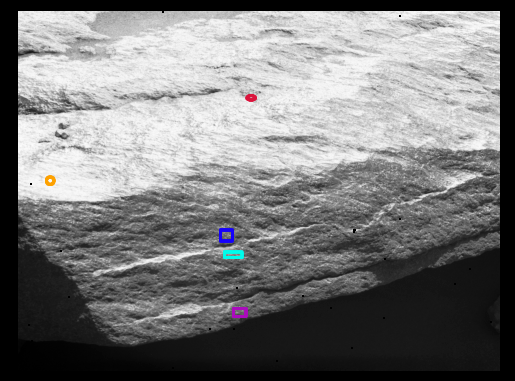

In [35]:
edge = draw_edgemaps_on_image(image, edgemaps)

In [ ]:
xyzm = np.ma.dstack([maps[ax] for ax in ('x', 'y', 'z')])

In [ ]:
%matplotlib qt

In [14]:
rangefig.show()

/tmp/ipykernel_1068/2106007570.py:1: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  rangefig.show()


In [15]:
spacing = 150
for ax0, ax1 in zip(('i', 'j'), ('j', 'i')):
    rec0, rec1 = axes[ax0], axes[ax1]
    rec0['length'], rec0['pos'], rec0['min'], rec0['max'] = [], [], [], []
#     if ax0 == 'j':
#          nodes = np.arange(spacing, rec1['pix'], spacing)
#     else:
#         nodes = np.arange(0, rec['pix'] - spacing - 1, spacing)
    nodes = np.arange(spacing, rec1['pix'] - spacing + 1, spacing)
    for node in nodes:
        ax_ix = rec1['unique'][np.abs((rec1['unique'] - node)).argmin()]
        line = rec0['valid'][rec1['valid'] == ax_ix]
        order = slice(None, None, -1) if ax0 == 'i' else slice(None, None, 1)
        anchors = line.min(), line.max()
        length = np.linalg.norm(
            xyz[(anchors[0], ax_ix)[order]] - xyz[(anchors[1], ax_ix)[order]]
        )
        if length < 1:
            length = np.round(length * 100, 1)
            length = f"{str(length)}cm"
        else:
            length = np.round(length, 2)
            length = f"{str(length)}m"
        rec0['length'].append(length)
        rec0['pos'].append(ax_ix)
        rec0['min'].append(anchors[0])
        rec0['max'].append(anchors[1])

NameError: name 'xyz' is not defined

In [ ]:
image = iof_data.get_scaled('IMAGE')

In [ ]:
fig, ax = plt.subplots()
ax.imshow(image)
style = {'linewidth': 6, 'color': (0, 0, 0, 0.8)}
ax.hlines(axes['i']['pos'], axes['i']['min'], axes['i']['max'], **style)
ax.vlines(axes['j']['pos'], axes['j']['min'], axes['j']['max'], **style)
ax.set_yticks(axes['i']['pos'], axes['i']['length'])
ax.set_xticks(axes['j']['pos'], axes['j']['length'])
despine(ax)

In [ ]:
incidence_map

In [ ]:
fig.show()

In [ ]:
maps.keys()

In [ ]:
plt.imshow(image_rgb)
plt.scatter(
    maps['i'], maps['j'], c=imesh[ji], cmap='cool', s=2
)

In [ ]:
plt.imshow(imesh, interpolation='none')

1. incidence maps (definitely, when available)
2. continuous rangemaps
    a. overlaid (definitely)
    b. plain (maybe)
3. range contour maps (pretty definitely)
    a. center at boresight / camera position given some instrument elevation cutoff
4. ROI dimensions, including surface area, maybe also diagonals (highest priority)
    a. maybe a browse product rendering scale bars
    b. maybe just a table
5. ROI incidence angle statistics (when available)
6. quality metrics based on density of source points (necessary but not for MVP)
    a. when available we could range/xyz error data from the source
    b. browse "goodness" map
    c. aggregated tabular values possibly per-ROI or maybe a backplane
        i. or both
7. full-image scalebar product (definitely)
8. orthorectified images (maybe)

In [ ]:
plt.imshow(r2_data.IMAGE)

In [ ]:
mpl.style.use('dark_background')
plt.imshow(imesh, interpolation='none', cmap='winter')

In [ ]:
si, sj = rec['coords']['si'], rec['coords']['sj']

In [ ]:
plt.imshow(
    nxyz[sj.min():sj.max(), si.min():si.max(), 1]
)

In [ ]:
nzy, nzx = np.nonzero(rangemesh)

In [ ]:
plt.figure()
plt.imshow(image, cmap='Greys_r')
plt.scatter(
    nzx, nzy, c=(rangemesh[nzy, nzx]), cmap='jet', s=20
)
plt.colorbar()

In [ ]:
from astropy.io import fits

In [ ]:
rangemesh[(nzy, nzx)].shape

In [ ]:
hdul.writeto('test.fits', overwrite=True)

In [ ]:
plt.figure()
plt.imshow(rangemap, cmap='Greys_r')
plt.colorbar()

In [ ]:
fits.open('test.fits')[1].data

In [ ]:
rangemap = make_rangemap(xyz)
plt.figure()
plt.imshow(rangemap)
plt.colorbar()

In [ ]:
plt.imshow(np.clip(off, 0, 45), cmap='Greys_r')
plt.colorbar()

In [ ]:
xyrs

In [ ]:
plt.imshow(mesh[:, :, 1], interpolation=None, cmap='Greys')

In [ ]:
plt.imshow(r2_data['IMAGE'])

In [ ]:
np.linalg.norm(xyz[545, 869])

In [ ]:
plt.imshow(xyz - xyz[624, 804])

In [ ]:
np.linalg.norm(xyz[1161, 1451] - xyz[1020, 1356])

In [ ]:

# flatten_into_figure([image_rgb, stretched])

In [ ]:
colormapped_plot

In [ ]:
rec

In [ ]:
flatten_into_figure(
    r2_data.IMAGE

In [ ]:
rangemap = np.linalg.norm(xyz - xyz[624, 804], axis=-1)
# np.percentile(rangemap[np.isfinite(rangemap)], (10, 90))
plt.figure()
plt.imshow(rangemap)

In [ ]:
plt.imshow(image)

In [ ]:
plt.figure()
plt.imshow(rangemap)
plt.colorbar()

In [ ]:
1

In [ ]:
from pathlib import Path

In [ ]:
from killscreen.aws.s3 import Bucket, ls_multipart, abort_multipart_upload
storm = Bucket('storm-king-mountain')

In [ ]:
storm.df

In [ ]:
existing = storm.df['Key'].tolist()

In [13]:
storm.put??

Object `storm.put` not found.


In [ ]:
for sol in Path("/datascratch/zcam_data/products/").iterdir():
    for dirtype in ("xyr", "uvw"):
        if not Path(sol, dirtype).exists():
            continue
        for f in Path(sol, dirtype).iterdir():
            target = f"products/{sol.name}/{dirtype}/{f.name}"
            if target in existing:
                print(f"{f.name} already exists")
                continue
            storm.put(f, target)
            print(f"copied {f.name}")

In [ ]:
plt.contour??

In [ ]:
plt.style.library.keys()

In [ ]:
zc['C']

In [ ]:
zc['Vc'], zc['Hc']

In [ ]:
zc['C']

In [ ]:
xyz[int(zc['Vc']), int(zc['Hc'])]

In [ ]:
boresight_range

In [ ]:
make_rangemap??

In [ ]:
# # for interpolating multiples...
# # work needs to be done to deal with banding etc.
# flats, meshes = [], []
# for rec in nav_recs:
#     coords = rec['coords']
#     canvas = np.zeros((*r2_data.IMAGE.shape, 3), np.float32)
#     for ax_ix, ax in enumerate(('x', 'y', 'z')):
#         canvas[coords['j'], coords['i'], ax_ix] = coords[ax]
#     meshes.append(canvas)
# pointcounts = np.sum([m[:, :, 0] != 0 for m in meshes], axis=0)
# mesh = np.einsum('ijk,ij->ijk', np.sum(meshes, axis=0), 1 / pointcounts)
# mesh[~np.isfinite(mesh)] = 0
# interp_tracker = np.full(r2_data.IMAGE.shape, 1, np.float32)
# ji = np.nonzero(mesh[:, :, 0])
# interp_tracker[ji] = 0
# missing_ji = np.nonzero(interp_tracker)

In [ ]:
uvw.dtype

In [ ]:
# alpha = 0.6
# xyz_filled = np.dstack(list(gridded.values()))
# xyz_filled = np.ma.masked_invalid(xyz_filled)
# stretched = enhance_color(xyz_filled, (0, 1), (1))
# stretched = np.dstack([stretched, np.full_like(xyz_filled, alpha)])
# image = normalize_range(r2_data.get_scaled('IMAGE'), (0, 1), 1)
# image_rgb = np.dstack([image] * 3)
# flats.append(flatten_into_figure([image_rgb, stretched]))

stop = time.time()

In [ ]:
stop - start

In [ ]:
raise ValueError

In [ ]:
plt.imshow(gridded['z'])

In [ ]:
numpy downample

In [ ]:
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))
ax.scatter3D(
    xyz[:, :, 0].ravel()[::50],
    xyz[:, :, 1].ravel()[::50],
    xyz[:, :, 2].ravel()[::50],
    c = image.ravel()[::50]
)

In [ ]:
plt.imshow(mesh, interpolation='none')

In [ ]:
plt.close('all')

In [ ]:
ax.plot_surface??

In [ ]:
fig.show()

In [ ]:
mmean = (meshes[4] + meshes[6]) / 2

In [ ]:
distance = np.linalg.norm(xyz_filled, axis=2)

In [ ]:
fig, ax = plt.subplots()

In [ ]:
plt.imshow(off)

In [ ]:
ax.imshow(distance, cmap='cividis')

In [ ]:
r2_data.metaget('SOLAR_ELEVATION')

In [ ]:
np.nanmean(off)

In [ ]:
griddata(ji[:, 0], ji[:, 1])

In [ ]:
ji[:, 0].argsort()

In [ ]:
ji[:, 1].argsort()

In [ ]:
ji[:, 0]

In [ ]:
RegularGridInterpolator((ji[:, 0], ji[:, 1]), xyz[0])

In [ ]:
interp2d?

In [ ]:
ix = 11022
cahvore = zc
relpos, xyz = relative_positions[ix], possible_xyz[ix]
omega = np.dot(relpos, cahvore['O'])
wo = omega * cahvore['O']
lambda3 = relpos - wo
tau = np.dot(lambda3, lambda3) / omega ** 2
r1, r2, r3 = cahvore['R']
mu = r1 + r2 * tau + r3 * tau ** 2
pp = mu * lambda3 + xyz
pp_c = pp - cahvore['C']
ppc_dot_a = np.dot(pp_c, cahvore['A'])
res = {
    'ij': (
        np.dot(pp_c, cahvore['H']) / ppc_dot_a - 1,
        np.dot(pp_c, cahvore['V']) / ppc_dot_a - 1
    ), 
    'xyz': xyz
}

In [ ]:
## i think this works, though!


# what do a lot of these variables stand for? incomprehensible
def xyz2ij(xyz, relpos, cahvore):
    omega = np.dot(relpos, cahvore['O'])
    wo = omega * cahvore['O']
    lambda3 = relpos - wo
    tau = np.dot(lambda3, lambda3) / omega ** 2
    r1, r2, r3 = cahvore['R']
    mu = r1 + r2 * tau + r3 * tau ** 2
    pp = mu * lambda3 + xyz
    pp_c = pp - cahvore['C']
    ppc_dot_a = np.dot(pp_c, cahvore['A'])
    return {
        'ij': (
            np.dot(pp_c, cahvore['H']) / ppc_dot_a - 1,
            np.dot(pp_c, cahvore['V']) / ppc_dot_a - 1
        ), 
        'xyz': xyz
    }

In [ ]:
omega = np.dot(relative_positions, zc['O'])

In [ ]:
located = [xyz2ij(xyz, relpos, zc) for xyz, relpos in zip(possible_xyz, relative_positions)]

In [ ]:
valid_ij = []
for coord in ij:
    if not 0 <= coord[0] <= 1648:
        continue
    if not 0 <= coord[1] <= 1200:
        continue
    valid_ij.append(coord)

In [ ]:
len(valid_ij)

In [ ]:
ij[-10]

In [ ]:
r2_data.IMAGE.shape

In [ ]:
# maybe unnecssary?
zcam_edges = get_valid_edges(r2_data.get_scaled('IMAGE'))
zcam_edge_rays = {
    k: ij_to_ray(yx[1], yx[0], zc)
    for k, yx in zcam_edges.items()
}

In [ ]:
# not sure this cross product is useful
# pos_cross_a_mag = np.linalg.norm(pos_cross_a, axis=2)
# pos_cross_a_u = np.einsum('ijk,ij->ijk', pos_cross_a, 1 / pos_cross_a_mag)
# i think taking these dot products is incoherent...
# pos_cross_a_dot_h = np.dot(pos_cross_a_u, zc['Hu'])
# pos_cross_a_dot_v = np.dot(pos_cross_a_u, zc['Vu'])
# not sure these dot products are useful
# pos_dot_h = np.dot(rel_pos_u, zc['Hu'])
# pos_dot_v = np.dot(rel_pos_u, zc['Vu'])

In [ ]:
plt.imshow(rough_valid_area)
bigmask = np.logical_or(nxyz.mask, np.dstack([~rough_valid_area]*3))
nxyz_v = nxyz.copy()
nxyz_v.mask = bigmask
nxyz_v[nxyz_v.mask] = 0
plt.figure()
plt.imshow(nxyz_v)

In [ ]:
# xyr = open_attached(xyrs[1])
# nav_cahvore = get_cahvore(xyr)
# (xyr.metaget('STEREO_PRODUCT_ID'), xyr.metaget('SOURCE_PRODUCT_ID'), xyr.metaget('INPUT_PRODUCT_ID'))
# nav_input = pdr.read(
#     '/datascratch/zcam_data/products/0092/nav/NLFC0092_0675117098_000RASLN0040136NCAM00699_0A00LLJ01.IMG'
# )
# navim = normalize_range(np.moveaxis(nav_input.IMAGE, 0, 2), (0, 1), 1)
# plt.figure()
# plt.imshow(navim)
# plt.figure()
# plt.imshow(np.sqrt(nxyz[:, :, 0] + 1))

In [ ]:
from scipy.spatial.transform import Rotation

In [ ]:
Rotation.from_rotvec()

In [ ]:
plt.imshow(np.sqrt(nxyz[:, :, 0]))

see: https://pds-imaging.jpl.nasa.gov/data/mer/spirit/mer2no_0xxx/document/geometric_cm.txt

so what is this ij_to_ray?

in CAHV model strictly: 

```
Given a 3D point P, the image coordinates may be computed as

             (P-C)*H         (P-C)*V 
         X = -------     Y = -------        
             (P-C)*A         (P-C)*A 

         (Note: * = vector dot product)
```

the dot product is of course not injective, so these equations cannot simply be inverted.

note, though, that A, H, V are _close_ to mutually orthogonal even given the ORE parameters...


```
A projection of this vector into the image plane,
called H', shows how the horizontal image dimension (the rows)
are oriented in 3D.The magnitude of this projection is, for an
ideal thin lens, the distance between the lens center and the
image plane, as measured in horizontal pixels; this value is
called the Horizontal Scale, and is often written as Hs.
(Contrary to what has been suggested elsewhere, Hs is not the focal length.)
[and then the same is true for V/vertical pixels]

```

```
H' = H-(A*H)A     Hs = |AxH|    Hc = A*H
```

```
Note that H' and V' are not necessarily exactly perpendicular to each
other. The angle between them, theta, is a measure of the spatial
relationship of the rows and columns. They are usually very close to
perpendicular, but have sometimes been observed to fall more than a
standard deviation away from that ideal.

                             (   VxH*A   ) 
               Theta = arctan(-----------) 
                             ((AxV)*(AxH))
```

In [ ]:
zcam_cahvore = derive_cahvore_properties(zcam_cahvore)

In [ ]:
zcam_cahvore

In [ ]:
zcam_cahvore['H_image'] / zcam_cahvore['Hs']

In [ ]:
np.linalg.norm(zcam_cahvore['V'])

In [ ]:
plt.imshow(r2.get_scaled('IMAGE'))

In [ ]:
# so i think we're talking about like y=2313, x=2680 for center of zcam image in xyr image coords

In [ ]:
xyz_rov = nxyz[2313, 2680].data

In [ ]:
xyz_rov

In [ ]:
plt.figure()
plt.imshow(np.clip(nxyz[:, :, 1], 0.2, 0.8))

In [ ]:
zcam_cahvore['C'], zcam_cahvore['A']

In [ ]:
test_position = zcam_cahvore['C'] + zcam_cahvore['A'] * 4
# zcam_cahvore['H'], zcam_cahvore['V']

In [ ]:
h_hat = zcam_cahvore['H'] / np.linalg.norm(zcam_cahvore['H'])
v_hat = zcam_cahvore['V'] / np.linalg.norm(zcam_cahvore['V'])
a_hat = zcam_cahvore['A'] / np.linalg.norm(zcam_cahvore['A'])

In [ ]:
az_fov = r2

In [ ]:
  AZIMUTH_FOV                     = 6.36042 <deg>
  ELEVATION_FOV                   = 4.63709 <deg>
  BAYER_METHOD                    = IDENTITY
  CFA_TYPE                        = BAYER_RGGB
  CFA_VENUE                       = ONBOARD
  DETECTOR_FIRST_LINE             = 1
  DETECTOR_FIRST_LINE_SAMPLE      = 1
  DETECTOR_LINES                  = 1200
  DETECTOR_LINE_SAMPLES           = 1648

In [ ]:
np.degrees(np.arccos(np.dot(a_hat, v_hat)))

In [ ]:
len(np.nonzero(~nxyz.mask)[0]) * 200

In [ ]:
i, j

In [ ]:
# # this should be cool but in fact will need more work to be cool
# from marslab.imgops.imgutils import enhance_color
# im = np.moveaxis(im, 0, 2)
# display = enhance_color(im, (0, 1), 1)
# plt.imshow(display)